# 04. Unit Economics

**Notebook objective:** to calculate unit economics for the online school at the product level.

The calculation is based on the cleaned datasets prepared in `02_data_cleaning`.  
The main analysis level is `Product`.

The analysis covers:

- unit economics calculation by product;
- contribution margin assessment;
- growth point identification;
- experiment duration estimation for hypothesis testing.

The methodology follows the course framework: `UA`, `AC` and `CPA` are calculated at the overall business level, while product-specific metrics are calculated separately for each product.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import importlib
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:,.2f}'.format)

In [2]:
# Define project paths so the notebook can be run from the repository structure
current_path = Path.cwd()
PROJECT_ROOT = current_path.parent if current_path.name == 'notebooks' else current_path

PROCESSED_DATA_PATH = PROJECT_ROOT / 'data' / 'processed'

PROCESSED_DATA_PATH


PosixPath('/Users/uliakardenasvalin/Documents/Аналитик данных/online-school-performance-analytics-portfolio/data/processed')

In [3]:
# Add the notebooks folder to the Python path for custom helper functions
NOTEBOOKS_PATH = PROJECT_ROOT / 'notebooks'
sys.path.append(str(NOTEBOOKS_PATH))

import project_util
importlib.reload(project_util)

from project_util import (
    safe_divide,
    dict_to_check_df,
    check_required_columns
)


## Loading Cleaned Data

The unit economics calculation uses the cleaned files prepared during the data cleaning stage.

After the cleaned datasets are finalized, the data is no longer adjusted manually. All calculations are based on the already prepared clean data.


In [4]:
# Check that the processed data folder is available
if not PROCESSED_DATA_PATH.exists():
    raise FileNotFoundError(f'Processed data folder not found: {PROCESSED_DATA_PATH}')

sorted([file.name for file in PROCESSED_DATA_PATH.glob('*')])


['best_growth_points.csv',
 'calls_clean.csv',
 'calls_clean.xlsx',
 'contacts_clean.csv',
 'contacts_clean.xlsx',
 'daily_ua_summary.csv',
 'deals_clean.csv',
 'deals_clean.xlsx',
 'experiment_hypothesis.csv',
 'experiment_summary.csv',
 'growth_scenarios_display.csv',
 'products_status.csv',
 'revenue_comparison.csv',
 'spend_clean.csv',
 'spend_clean.xlsx',
 'unit_economics_check.csv',
 'unit_economics_display.csv',
 'unit_economics_total.csv']

In [5]:
deals = pd.read_csv(PROCESSED_DATA_PATH / 'deals_clean.csv')
contacts = pd.read_csv(PROCESSED_DATA_PATH / 'contacts_clean.csv')
calls = pd.read_csv(PROCESSED_DATA_PATH / 'calls_clean.csv')
spend = pd.read_csv(PROCESSED_DATA_PATH / 'spend_clean.csv')


In [6]:
print('Deals:', deals.shape)
print('Contacts:', contacts.shape)
print('Calls:', calls.shape)
print('Spend:', spend.shape)

Deals: (21593, 34)
Contacts: (18548, 5)
Calls: (95874, 10)
Spend: (20779, 11)


After loading the CSV files, I check and restore data types where needed. Some types may change when the cleaned datasets are saved and read again.


In [7]:
# Date columns

date_columns_deals = [
    'Created Time',
    'Created Date',
    'Closing Date',
    'Closing Date Only'
]

for col in date_columns_deals:
    if col in deals.columns:
        deals[col] = pd.to_datetime(deals[col], errors='coerce')

if 'Created Time' in contacts.columns:
    contacts['Created Time'] = pd.to_datetime(contacts['Created Time'], errors='coerce')

if 'Modified Time' in contacts.columns:
    contacts['Modified Time'] = pd.to_datetime(contacts['Modified Time'], errors='coerce')

if 'Call Start Time' in calls.columns:
    calls['Call Start Time'] = pd.to_datetime(calls['Call Start Time'], errors='coerce')

if 'Date' in spend.columns:
    spend['Date'] = pd.to_datetime(spend['Date'], errors='coerce')


In [8]:
# SLA

if 'SLA' in deals.columns:
    deals['SLA'] = pd.to_timedelta(deals['SLA'], errors='coerce')

## Data Structure Check

In [9]:
required_columns = {
    'deals': [
        'Id',
        'Stage',
        'Product',
        'Months of study',
        'Course duration',
        'Initial Amount Paid',
        'Offer Total Amount'
    ],
    'contacts': [
        'Id'
    ],
    'calls': [
        'Id',
        'CONTACTID'
    ],
    'spend': [
        'Spend'
    ]
}

dataframes = {
    'deals': deals,
    'contacts': contacts,
    'calls': calls,
    'spend': spend
}

missing_columns_check_df = check_required_columns(
    dataframes=dataframes,
    required_columns=required_columns
)

missing_columns_check_df

,Table,Missing Columns,Missing Columns Count
0,deals,[],0
1,contacts,[],0
2,calls,[],0
3,spend,[],0


# Unit Economics Calculation Methodology

The main calculation level is `Product`.

In the previous notebook, `03_eda_business_analysis`, the financial analysis was based on payments actually recorded in CRM: `Initial Amount Paid`, actual revenue, average check and median check.

This notebook calculates unit economics. For this purpose, two additional customer-level metrics are calculated:

- `AOV_I` — estimated average monthly payment per customer;
- `Revenue_I` — estimated revenue per customer for the actual study period.

These metrics are needed because a customer may study for several months and may not pay the full course price upfront. Therefore, for unit economics, it is important to estimate not only the first payment but also revenue based on `Months of study`, `Course duration`, `Initial Amount Paid` and `Offer Total Amount`.

## Metrics and Formulas

- `UA` — number of potential customers / leads.  
  Formula: `UA = max(unique contacts in Contacts, Deals, Calls)`.

- `B` — number of customers by product.  
  Formula: `B = count of paid customers by Product`, where `Stage = Payment Done` and `Months of study > 0`.

- `C1` — lead-to-customer conversion.  
  Formula: `C1 = B / UA`.

- `AC` — marketing acquisition cost.  
  Formula: `AC = sum(Spend)`.

- `CPA` — cost per potential customer.  
  Formula: `CPA = AC / UA`.

- `CAC` — customer acquisition cost.  
  Formula: `CAC = AC / B`.

- `T` — number of transactions. In this methodology, it is calculated using the number of study months.  
  Formula: `T = sum(Months of study)`.

- `AOV_I` — estimated average monthly payment per customer.  
  If `Offer Total Amount > Initial Amount Paid`, the formula is:  
  `AOV_I = (Initial Amount Paid + (Months of study - 1) * (Offer Total Amount - Initial Amount Paid) / (Course duration - 1)) / Months of study`.

  Otherwise:  
  `AOV_I = Offer Total Amount / Course duration`.

- `Revenue_I` — estimated revenue per customer for the actual study period.  
  Formula: `Revenue_I = AOV_I * Months of study`.

- `Revenue` — estimated product-level revenue for unit economics.  
  Formula: `Revenue = sum(Revenue_I)`.

- `AOV` — average transaction value / average monthly payment by product.  
  Formula: `AOV = Revenue / T`.

- `APC` — average number of transactions / study months per customer.  
  Formula: `APC = T / B`.

- `CLTV` — average gross profit per customer.  
  Formula: `CLTV = AOV * APC`.

- `LTV` — average gross profit per lead.  
  Formula: `LTV = CLTV * C1`.

- `CM` — contribution margin.  
  Formula: `CM = UA * (LTV - CPA)`.

- `ROMI` — return on marketing investment.  
  Formula: `ROMI = CM / AC`.

According to the methodology, `UA`, `AC` and `CPA` are common for all products. Product-level differences are driven by `B`, `C1`, `T`, `AOV`, `APC`, `Revenue`, `CLTV`, `LTV`, `CAC`, `CM` and `ROMI`.

Since cost-of-goods-sold data is not available in the dataset, `COGS` is assumed to be 0.


## Product List

First, I define the list of products for the unit economics calculation.

The calculation uses products available in the cleaned `Deals` table.


In [10]:
products = (
    deals['Product']
    .dropna()
    .drop_duplicates()
    .sort_values()
    .tolist()
)

products

['Data Analytics',
 'Digital Marketing',
 'Find yourself in IT',
 'UX/UI Design',
 'Unknown',
 'Web Developer']

In [11]:
# Exclude Unknown from the product-level calculation

products_for_unit = [
    product for product in products
    if product != 'Unknown'
]

products_for_unit


['Data Analytics',
 'Digital Marketing',
 'Find yourself in IT',
 'UX/UI Design',
 'Web Developer']

## Preparing the Calculation Base for Unit Economics

Customer-level and product-level metrics are calculated using deals that meet the following conditions:

- `Stage = Payment Done`;
- `Product` is filled in and is not equal to `Unknown`;
- `Months of study > 0`.


In [12]:
unit_deals = deals[
    (deals['Stage'] == 'Payment Done') &
    (deals['Product'].notna()) &
    (deals['Product'] != 'Unknown') &
    (deals['Months of study'].notna()) &
    (deals['Months of study'] > 0)
].copy()

unit_deals['Product'].value_counts(dropna=False)

Product
Digital Marketing    474
UX/UI Design         228
Web Developer        137
Name: count, dtype: int64

In [13]:
products_with_clients = (
    unit_deals['Product']
    .dropna()
    .drop_duplicates()
    .sort_values()
    .tolist()
)

products_status = pd.DataFrame({
    'Product': products_for_unit
})

products_status['Has Customers in Calculation Base'] = np.where(
    products_status['Product'].isin(products_with_clients),
    'Yes',
    'No'
)

products_status['Status'] = np.where(
    products_status['Has Customers in Calculation Base'] == 'Yes',
    'Included in unit economics calculation',
    'Included only in the base table'
)

products_status


,Product,Has Customers in Calculation Base,Status
0,Data Analytics,No,Included only in the base table
1,Digital Marketing,Yes,Included in unit economics calculation
2,Find yourself in IT,No,Included only in the base table
3,UX/UI Design,Yes,Included in unit economics calculation
4,Web Developer,Yes,Included in unit economics calculation


## Customer-Level Revenue Calculation for Unit Economics

For unit economics, average order value and revenue are calculated at the customer level.

`AOV_I` is the estimated average monthly payment per customer, based on:

- first payment;
- total offer amount;
- course duration;
- actual number of study months.

Formula:

If `Offer Total Amount > Initial Amount Paid`:

`AOV_I = (Initial Amount Paid + (Months of study - 1) * (Offer Total Amount - Initial Amount Paid) / (Course duration - 1)) / Months of study`

Otherwise:

`AOV_I = Offer Total Amount / Course duration`

---

Then customer-level revenue for the actual study period is calculated:

`Revenue_I = AOV_I * Months of study`


In [14]:
def calculate_aov_i(row):
    """
    Calculate AOV_I for one row for the unit economics model.

    Fields used:
    - Initial Amount Paid
    - Offer Total Amount
    - Months of study
    - Course duration
    """
    initial_amount = row['Initial Amount Paid']
    offer_total = row['Offer Total Amount']
    months_of_study = row['Months of study']
    course_duration = row['Course duration']

    if pd.isna(initial_amount) or pd.isna(offer_total):
        return np.nan

    if pd.isna(months_of_study) or months_of_study <= 0:
        return np.nan

    if pd.isna(course_duration) or course_duration <= 0:
        return np.nan

    if offer_total - initial_amount > 0:

        if course_duration - 1 <= 0:
            return np.nan

        aov_i = (
            initial_amount
            + (months_of_study - 1)
            * (offer_total - initial_amount)
            / (course_duration - 1)
        ) / months_of_study

    else:
        aov_i = offer_total / course_duration

    return aov_i


In [15]:
unit_deals['AOV_I'] = unit_deals.apply(
    calculate_aov_i,
    axis=1
)

unit_deals['Revenue_I'] = (
    unit_deals['AOV_I'] *
    unit_deals['Months of study']
)

In [16]:
unit_deals[
    [
        'Product',
        'Initial Amount Paid',
        'Offer Total Amount',
        'Course duration',
        'Months of study',
        'AOV_I',
        'Revenue_I'
    ]
].head(20)

,Product,Initial Amount Paid,Offer Total Amount,Course duration,Months of study,AOV_I,Revenue_I
468,Digital Marketing,500.00,"4,500.00",11.00,1.00,500.00,500.00
478,Digital Marketing,500.00,"4,500.00",11.00,1.00,500.00,500.00
497,Web Developer,"1,000.00","9,000.00",6.00,1.00,"1,000.00","1,000.00"
833,Web Developer,"1,000.00","9,000.00",6.00,1.00,"1,000.00","1,000.00"
1040,Digital Marketing,"1,000.00","11,000.00",11.00,1.00,"1,000.00","1,000.00"
1065,Digital Marketing,"1,000.00","11,000.00",11.00,1.00,"1,000.00","1,000.00"
1073,Digital Marketing,"1,000.00","11,000.00",11.00,1.00,"1,000.00","1,000.00"
1121,UX/UI Design,"1,000.00","11,000.00",11.00,1.00,"1,000.00","1,000.00"
1178,UX/UI Design,"1,000.00","11,000.00",11.00,1.00,"1,000.00","1,000.00"
1215,Digital Marketing,"1,000.00","11,000.00",11.00,1.00,"1,000.00","1,000.00"


## Checking AOV_I and Revenue_I Calculation

I check how many rows received calculated `AOV_I` and `Revenue_I` values and review their basic distributions.


In [17]:
aov_revenue_check = {
    'Rows in unit_deals': unit_deals.shape[0],
    'AOV_I filled': unit_deals['AOV_I'].notna().sum(),
    'AOV_I missing': unit_deals['AOV_I'].isna().sum(),
    'Revenue_I filled': unit_deals['Revenue_I'].notna().sum(),
    'Revenue_I missing': unit_deals['Revenue_I'].isna().sum(),
    'Revenue_I total': unit_deals['Revenue_I'].sum()
}

aov_revenue_check_df = dict_to_check_df(
    aov_revenue_check,
    key_col='Check',
    value_col='Value'
)

aov_revenue_check_df


,Check,Value
0,Rows in unit_deals,839.00
1,AOV_I filled,839.00
2,AOV_I missing,0.00
3,Revenue_I filled,839.00
4,Revenue_I missing,0.00
5,Revenue_I total,"3,374,357.12"


In [18]:
unit_deals[['AOV_I', 'Revenue_I']].describe()

,AOV_I,Revenue_I
count,839.00,839.00
mean,753.08,"4,021.88"
std,326.76,"2,905.53"
min,0.00,0.00
25%,360.00,"1,810.00"
50%,"1,000.00","3,000.00"
75%,"1,000.00","6,000.00"
max,"2,000.00","11,500.00"


In [19]:
revenue_i_by_product = (
    unit_deals
    .groupby('Product')
    .agg(
        deals_count=('Id', 'count'),
        revenue_i=('Revenue_I', 'sum'),
        avg_aov_i=('AOV_I', 'mean')
    )
    .reset_index()
    .rename(columns={
        'deals_count': 'Deals Count',
        'revenue_i': 'Revenue_I',
        'avg_aov_i': 'Avg AOV_I'
    })
    .sort_values('Revenue_I', ascending=False)
)

revenue_i_by_product

,Product,Deals Count,Revenue_I,Avg AOV_I
0,Digital Marketing,474,"2,148,610.91",758.38
1,UX/UI Design,228,"876,999.55",757.79
2,Web Developer,137,"348,746.67",726.91


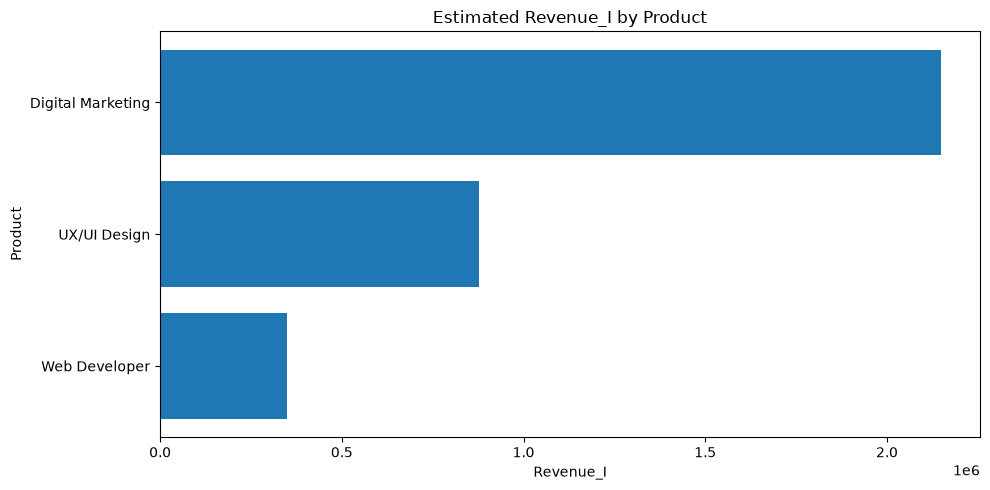

In [20]:
revenue_i_by_product_plot = revenue_i_by_product.sort_values(
    'Revenue_I',
    ascending=True
)

plt.figure(figsize=(10, 5))

plt.barh(
    revenue_i_by_product_plot['Product'],
    revenue_i_by_product_plot['Revenue_I']
)

plt.xlabel('Revenue_I')
plt.ylabel('Product')
plt.title('Estimated Revenue_I by Product')
plt.tight_layout()
plt.show()


## Comparing Actual Payments from EDA and Estimated Revenue for Unit Economics

In the EDA notebook, the financial analysis was based on the initially recorded payments from CRM (`Initial Amount Paid`).

In the unit economics model, estimated revenue `Revenue_I` is used. It accounts for the customer's actual study months and the full offer amount. Therefore, total `Revenue_I` may be higher than the sum of initial payments.

This is not a calculation error. It is a methodological difference: EDA shows recorded payment facts, while unit economics estimates customer revenue for the study period.


In [21]:
eda_paid_deals = deals[
    (deals['Stage'] == 'Payment Done') &
    (deals['Initial Amount Paid'].notna())
].copy()

eda_revenue_value = eda_paid_deals['Initial Amount Paid'].sum()
unit_revenue_value = unit_deals['Revenue_I'].sum()

revenue_comparison = pd.DataFrame({
    'Metric': [
        'Actual initial payments from EDA',
        'Estimated Revenue_I for unit economics',
        'Difference between Revenue_I and actual initial payments'
    ],
    'Value': [
        eda_revenue_value,
        unit_revenue_value,
        unit_revenue_value - eda_revenue_value
    ]
})

revenue_comparison['Value'] = revenue_comparison['Value'].round(2)

revenue_comparison


,Metric,Value
0,Actual initial payments from EDA,"978,651.00"
1,Estimated Revenue_I for unit economics,"3,374,357.12"
2,Difference between Revenue_I and actual initia...,"2,395,706.12"


## General Model Parameters: UA, AC and CPA

`UA` is the number of unique potential customers.

According to the methodology, `UA` is defined as the maximum number of unique contacts across three tables:

- `Contacts`;
- `Deals`;
- `Calls`.

This approach is used because contact identifiers may not fully match across the source tables.

`AC` is the total marketing acquisition cost.  
It is calculated as total advertising spend from the `Spend` table.

`CPA = AC / UA`.

Since `UA` and `AC` are common for all products, `CPA` is also the same for all products.


In [22]:
# Contacts

ua_contacts = contacts['Id'].nunique(dropna=True)

# Deals

ua_deals = deals['Contact Name'].nunique(dropna=True)

# Calls

ua_calls = calls['CONTACTID'].nunique(dropna=True)

In [23]:
ua_check = {
    'UA Contacts': ua_contacts,
    'UA Deals': ua_deals,
    'UA Calls': ua_calls
}

ua_check_df = dict_to_check_df(
    ua_check,
    key_col='Source',
    value_col='Unique Contacts Count'
)

ua_check_df


,Source,Unique Contacts Count
0,UA Contacts,18548
1,UA Deals,8266
2,UA Calls,7556


In [24]:
UA = max(ua_contacts, ua_deals, ua_calls)

print('Final UA value:', UA)


Final UA value: 18548


In [25]:
AC = spend['Spend'].sum()

CPA = AC / UA if UA != 0 else np.nan

ac_cpa_summary_df = pd.DataFrame({
    'Metric': ['UA', 'AC', 'CPA'],
    'Value': [
        UA,
        round(AC, 2),
        round(CPA, 2)
    ]
})

ac_cpa_summary_df


,Metric,Value
0,UA,"18,548.00"
1,AC,"149,523.45"
2,CPA,8.06


## Unit Economics Helper Functions

The following helper functions implement the unit economics formulas.


In [26]:
def scalar_safe_divide(numerator, denominator):
    """
    Safely divide two scalar numeric values.

    If the denominator is zero or missing, return NaN.
    """
    if pd.isna(denominator) or denominator == 0:
        return np.nan

    return numerator / denominator


In [27]:
def calculate_product_unit_economics(product, unit_deals, UA, AC, CPA):
    """
    Calculate unit economics for one product.
    """
    product_deals = unit_deals[
        unit_deals['Product'] == product
    ].copy()

    # B — number of customers.
    # In the current model, this equals the number of paid deals.
    B = product_deals['Id'].nunique()

    # T — number of transactions / study months.
    T = product_deals['Months of study'].sum()

    # Revenue — estimated revenue according to the unit economics model.
    Revenue = product_deals['Revenue_I'].sum()

    # COGS is not available in the data, so it is assumed to be 0.
    COGS = 0

    C1 = scalar_safe_divide(B, UA)
    AOV = scalar_safe_divide(Revenue, T)
    APC = scalar_safe_divide(T, B)
    CLTV = AOV * APC if pd.notna(AOV) and pd.notna(APC) else np.nan
    LTV = CLTV * C1 if pd.notna(CLTV) and pd.notna(C1) else np.nan
    CAC = scalar_safe_divide(AC, B)

    if pd.notna(LTV) and pd.notna(CPA):
        CM = UA * (LTV - CPA)
    else:
        CM = -AC

    ROMI = scalar_safe_divide(CM, AC)

    return {
        'Product': product,
        'UA': UA,
        'B': B,
        'C1': C1,
        'AC': AC,
        'CPA': CPA,
        'CAC': CAC,
        'COGS': COGS,
        'Revenue': Revenue,
        'T': T,
        'AOV': AOV,
        'APC': APC,
        'CLTV': CLTV,
        'LTV': LTV,
        'CM': CM,
        'ROMI': ROMI
    }


## Overall Unit Economics Without Product Breakdown

Before analyzing unit economics by product, I calculate the overall unit economics for the project without product segmentation.

This calculation shows the economics of the whole customer base:

- how many customers are included in the calculation base;
- how much estimated revenue is generated;
- what average order value, APC, CLTV and LTV are at the project level;
- what overall contribution margin and ROMI are.


In [28]:
# Overall unit economics without product breakdown

total_B = unit_deals['Id'].nunique()
total_T = unit_deals['Months of study'].sum()
total_Revenue = unit_deals['Revenue_I'].sum()
total_COGS = 0

total_C1 = scalar_safe_divide(total_B, UA)
total_AOV = scalar_safe_divide(total_Revenue, total_T)
total_APC = scalar_safe_divide(total_T, total_B)
total_CLTV = total_AOV * total_APC if pd.notna(total_AOV) and pd.notna(total_APC) else np.nan
total_LTV = total_CLTV * total_C1 if pd.notna(total_CLTV) and pd.notna(total_C1) else np.nan
total_CAC = scalar_safe_divide(AC, total_B)

if pd.notna(total_LTV) and pd.notna(CPA):
    total_CM = UA * (total_LTV - CPA)
else:
    total_CM = -AC

total_ROMI = scalar_safe_divide(total_CM, AC)

unit_economics_total = pd.DataFrame([{
    'UA': UA,
    'B': total_B,
    'C1, %': round(total_C1 * 100, 2),
    'AC': round(AC, 2),
    'CPA': round(float(CPA), 2),
    'CAC': round(total_CAC, 2),
    'COGS': total_COGS,
    'Revenue': round(total_Revenue, 2),
    'T': round(total_T, 2),
    'AOV': round(total_AOV, 2),
    'APC': round(total_APC, 2),
    'CLTV': round(total_CLTV, 2),
    'LTV': round(total_LTV, 2),
    'CM': round(total_CM, 2),
    'ROMI, %': round(total_ROMI * 100, 2)
}])

unit_economics_total

,UA,B,"C1, %",AC,CPA,CAC,COGS,Revenue,T,AOV,APC,CLTV,LTV,CM,"ROMI, %"
0,18548,839,4.52,"149,523.45",8.06,178.22,0,"3,374,357.12","4,572.00",738.05,5.45,"4,021.88",181.93,"3,224,833.67","2,156.74"


## Product-Level Unit Economics Table

At this step, I build the final unit economics table for each product.

The base table includes all real products from `Deals`, excluding `Unknown`.

Products without customers in `unit_deals` remain in the table to clearly show the product lines that are present in the data but do not have sales matching the unit economics calculation conditions.


In [29]:
unit_economics_rows = []

for product in products_for_unit:
    product_metrics = calculate_product_unit_economics(
        product=product,
        unit_deals=unit_deals,
        UA=UA,
        AC=AC,
        CPA=CPA
    )

    unit_economics_rows.append(product_metrics)

unit_economics = pd.DataFrame(unit_economics_rows)

unit_economics

,Product,UA,B,C1,AC,CPA,CAC,COGS,Revenue,T,AOV,APC,CLTV,LTV,CM,ROMI
0,Data Analytics,18548,0,0.00,"149,523.45",8.06,NaN,0,0.00,0.00,NaN,NaN,NaN,NaN,"-149,523.45",-1.00
1,Digital Marketing,18548,474,0.03,"149,523.45",8.06,315.45,0,"2,148,610.91","2,897.00",741.67,6.11,"4,532.93",115.84,"1,999,087.46",13.37
2,Find yourself in IT,18548,0,0.00,"149,523.45",8.06,NaN,0,0.00,0.00,NaN,NaN,NaN,NaN,"-149,523.45",-1.00
3,UX/UI Design,18548,228,0.01,"149,523.45",8.06,655.80,0,"876,999.55","1,170.00",749.57,5.13,"3,846.49",47.28,"727,476.10",4.87
4,Web Developer,18548,137,0.01,"149,523.45",8.06,"1,091.41",0,"348,746.67",505.00,690.59,3.69,"2,545.60",18.80,"199,223.22",1.33


### Formatting the Unit Economics Table

In [30]:
unit_economics_display = unit_economics.copy()

# Round numeric values for display
round_columns = [
    'AC',
    'CPA',
    'CAC',
    'Revenue',
    'T',
    'AOV',
    'APC',
    'CLTV',
    'LTV',
    'CM',
    'COGS'
]

for col in round_columns:
    unit_economics_display[col] = (
        unit_economics_display[col]
        .pipe(pd.to_numeric, errors='coerce')
        .round(2)
    )

# Convert shares to percentages
unit_economics_display['C1'] = (
    unit_economics_display['C1'] * 100
).round(2)

unit_economics_display['ROMI'] = (
    unit_economics_display['ROMI'] * 100
).round(2)

unit_economics_display = unit_economics_display.rename(columns={
    'C1': 'C1, %',
    'ROMI': 'ROMI, %'
})

# For products without customers, some customer metrics cannot be calculated
client_metric_columns = [
    'CAC',
    'AOV',
    'APC',
    'CLTV',
    'LTV'
]

unit_economics_display[client_metric_columns] = unit_economics_display[
    client_metric_columns
].fillna('-')

unit_economics_display

,Product,UA,B,"C1, %",AC,CPA,CAC,COGS,Revenue,T,AOV,APC,CLTV,LTV,CM,"ROMI, %"
0,Data Analytics,18548,0,0.00,"149,523.45",8.06,-,0,0.00,0.00,-,-,-,-,"-149,523.45",-100.00
1,Digital Marketing,18548,474,2.56,"149,523.45",8.06,315.45,0,"2,148,610.91","2,897.00",741.67,6.11,"4,532.93",115.84,"1,999,087.46","1,336.97"
2,Find yourself in IT,18548,0,0.00,"149,523.45",8.06,-,0,0.00,0.00,-,-,-,-,"-149,523.45",-100.00
3,UX/UI Design,18548,228,1.23,"149,523.45",8.06,655.80,0,"876,999.55","1,170.00",749.57,5.13,"3,846.49",47.28,"727,476.10",486.53
4,Web Developer,18548,137,0.74,"149,523.45",8.06,"1,091.41",0,"348,746.67",505.00,690.59,3.69,"2,545.60",18.80,"199,223.22",133.24


## Checking the Base Unit Economics Table

I check that the unit economics table has been calculated for all products and that key metrics do not contain unexpected missing values.

For products without sales, some metrics may be empty or negative. This is expected.


In [31]:
unit_economics_check = {
    'Products in calculation': unit_economics.shape[0],
    'Products with customers B > 0': (unit_economics['B'] > 0).sum(),
    'Products without customers B = 0': (unit_economics['B'] == 0).sum(),
    'Total Revenue by product': unit_economics['Revenue'].sum(),
    'Total CM by product': unit_economics['CM'].sum(),
    'Minimum CM': unit_economics['CM'].min(),
    'Maximum CM': unit_economics['CM'].max()
}

unit_economics_check_df = dict_to_check_df(
    unit_economics_check,
    key_col='Check',
    value_col='Value'
)

unit_economics_check_df


,Check,Value
0,Products in calculation,5.00
1,Products with customers B > 0,3.00
2,Products without customers B = 0,2.00
3,Total Revenue by product,"3,374,357.12"
4,Total CM by product,"2,626,739.87"
5,Minimum CM,"-149,523.45"
6,Maximum CM,"1,999,087.46"


## Visual Analysis of Unit Economics

For visualization, I use only products with `B > 0`.

Products without customers remain in the base table but are not used in the visual comparison of efficiency, because customer-level metrics cannot be interpreted correctly for them.


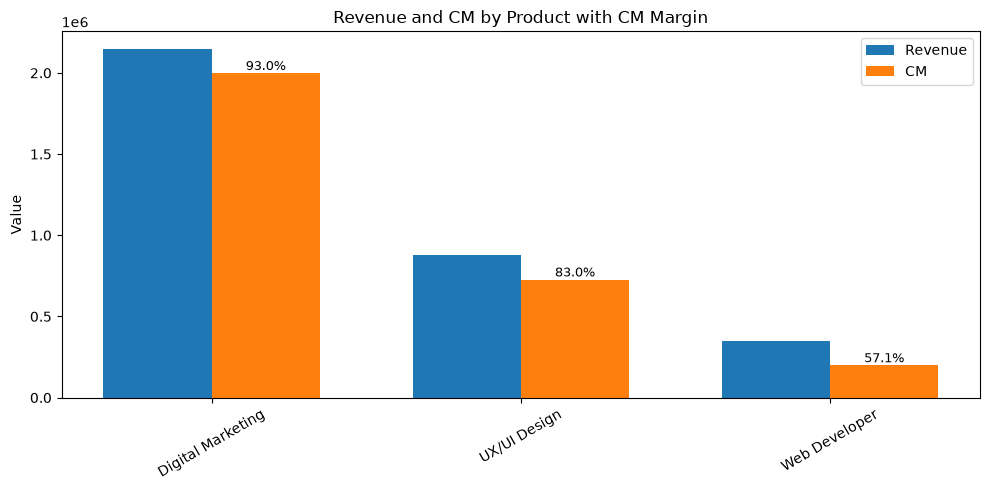

In [32]:
unit_economics_revenue_cm_plot = (
    unit_economics[unit_economics['B'] > 0]
    [['Product', 'Revenue', 'CM']]
    .copy()
    .sort_values('Revenue', ascending=False)
)

unit_economics_revenue_cm_plot['CM Margin, %'] = (
    unit_economics_revenue_cm_plot['CM'] /
    unit_economics_revenue_cm_plot['Revenue'] *
    100
)

x = np.arange(len(unit_economics_revenue_cm_plot['Product']))
width = 0.35

plt.figure(figsize=(10, 5))

plt.bar(
    x - width / 2,
    unit_economics_revenue_cm_plot['Revenue'],
    width,
    label='Revenue'
)

plt.bar(
    x + width / 2,
    unit_economics_revenue_cm_plot['CM'],
    width,
    label='CM'
)

for i, row in unit_economics_revenue_cm_plot.iterrows():
    position = list(unit_economics_revenue_cm_plot.index).index(i)

    plt.text(
        position + width / 2,
        row['CM'],
        f"{row['CM Margin, %']:.1f}%",
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.xticks(
    x,
    unit_economics_revenue_cm_plot['Product'],
    rotation=30
)

plt.ylabel('Value')
plt.title('Revenue and CM by Product with CM Margin')
plt.legend()

plt.tight_layout()
plt.show()

### Revenue and CM by Product

The chart compares estimated `Revenue` and contribution margin `CM` for products with customers.

Additionally, `CM Margin` is shown above the `CM` bars:

`CM Margin = CM / Revenue`

This chart helps evaluate not only product scale by revenue but also how much of estimated revenue remains as contribution margin.


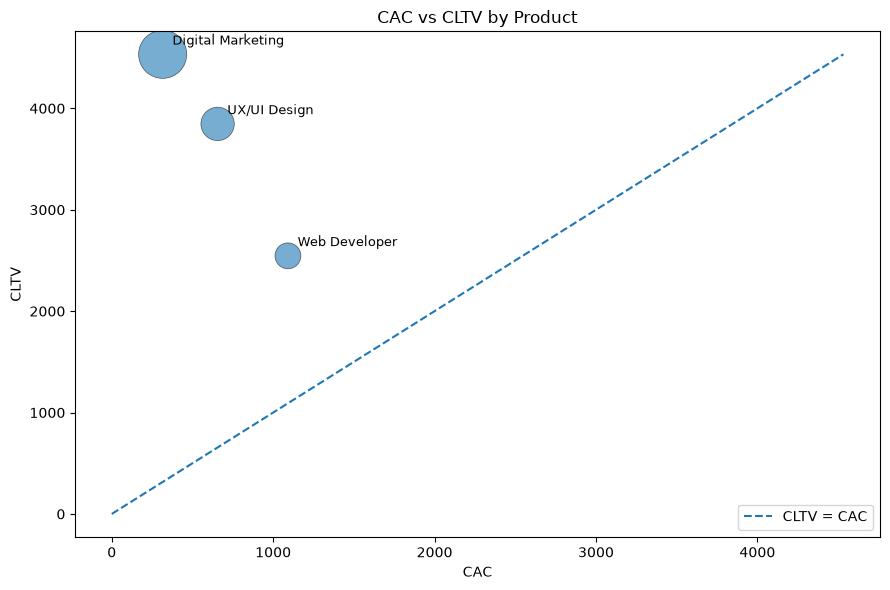

In [33]:
cac_cltv_plot = (
    unit_economics[
        (unit_economics['B'] > 0) &
        (unit_economics['CAC'].notna()) &
        (unit_economics['CLTV'].notna())
    ]
    .copy()
)

bubble_size = (
    cac_cltv_plot['B'] /
    cac_cltv_plot['B'].max() *
    1200
)

plt.figure(figsize=(9, 6))

plt.scatter(
    cac_cltv_plot['CAC'],
    cac_cltv_plot['CLTV'],
    s=bubble_size,
    alpha=0.6,
    edgecolors='black',
    linewidth=0.5
)

for _, row in cac_cltv_plot.iterrows():
    plt.annotate(
        row['Product'],
        xy=(row['CAC'], row['CLTV']),
        xytext=(7, 7),
        textcoords='offset points',
        fontsize=9
    )

max_value = max(
    cac_cltv_plot['CAC'].max(),
    cac_cltv_plot['CLTV'].max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle='--',
    linewidth=1.5,
    label='CLTV = CAC'
)

plt.xlabel('CAC')
plt.ylabel('CLTV')
plt.title('CAC vs CLTV by Product')
plt.legend()

plt.tight_layout()
plt.show()

### CAC vs CLTV by Product

The chart compares:

- `CAC` — customer acquisition cost;
- `CLTV` — average gross profit per customer.

The diagonal line shows the `CLTV = CAC` boundary.

If a product is above this line, its estimated customer value is higher than customer acquisition cost.

Bubble size reflects the number of customers `B` by product.


### Key Findings from the Baseline Unit Economics

First, the overall unit economics of the project was calculated without a product breakdown.

At the overall level, 839 customers are included in the calculation base. Total `UA` is 18,548, and lead-to-customer conversion `C1` is 4.52%. Total acquisition cost `AC` is 149,523.45, `CPA` is 8.06, and `CAC` is 178.22.

Estimated revenue for unit economics is 3,374,357.12. It is calculated not only from initial payments but also from the customer's actual study months, course duration, first payment and full offer amount. Therefore, it differs from actual initial payments from EDA: actual payments equal 978,651.00, while estimated `Revenue_I` equals 3,374,357.12. The difference is 2,395,706.12. This is expected because unit economics estimates customer revenue for the study period, not only the first recorded payment.

At the overall model level, `T` is 4,572, average transaction value `AOV` is 738.05, and average number of transactions per customer `APC` is 5.45. Average gross profit per customer `CLTV` is 4,021.88, and `LTV` per lead is 181.93.

Total project `CM` is 3,224,833.67, and `ROMI` is 2,156.74%. This means that, at the aggregate level, the project has positive unit economics: estimated revenue significantly exceeds total acquisition cost.

---

The product-level unit economics table includes five product lines available in the cleaned `Deals` table:

* `Data Analytics`;
* `Digital Marketing`;
* `Find yourself in IT`;
* `UX/UI Design`;
* `Web Developer`.

However, a full customer base for unit economics is available only for three products:

* `Digital Marketing`;
* `UX/UI Design`;
* `Web Developer`.

`Data Analytics` and `Find yourself in IT` are present in the data but have no customers in the calculation base: there are no rows that simultaneously meet the conditions `Stage = Payment Done` and `Months of study > 0`. Therefore, they are included only in the base table and are not used in the growth scenario analysis.

---

The main contribution to estimated revenue and contribution margin comes from `Digital Marketing`. It has 474 customers, estimated revenue of 2,148,610.91, and `CM` of 1,999,087.46. This is the strongest product in the current unit economics model. Its positive `ROMI` also confirms high payback of the product line.

`UX/UI Design` ranks second: 228 customers, estimated revenue of 876,999.55, and `CM` of 727,476.10. The product has positive contribution margin and makes a visible contribution to total profit, but it is smaller than `Digital Marketing` by customer base and total revenue.

`Web Developer` is also positive, but its contribution is lower: 137 customers, estimated revenue of 348,746.67, and `CM` of 199,223.22. It also has the highest `CAC` among the three products with customers — 1,091.41 — which is driven by a smaller number of customers under the common acquisition cost methodology.

---

It is important to distinguish between overall unit economics and the product-level view.

Since `UA`, `AC` and `CPA` are common for all products, product-level `CM` values should not be mechanically summed as a separate financial statement. The product-level view is used to compare product performance, identify growth opportunities and understand where improvement scenarios may have the strongest effect.


# Growth Point Analysis

At this step, I test which metric produces the highest `CM` uplift for each product.

The baseline scenario changes each metric by 5%:

- `UA + 5%`;
- `C1 + 5%`;
- `AOV + 5%`;
- `APC + 5%`;
- `CPA - 5%`.

The scenario analysis uses only products with customers (`B > 0`), because for products without customers, `C1`, `AOV`, `APC`, `CLTV`, `LTV` and `CAC` cannot be interpreted correctly.


In [34]:
growth_rate = 0.05

growth_products = (
    unit_economics[unit_economics['B'] > 0]['Product']
    .sort_values()
    .tolist()
)

growth_products

['Digital Marketing', 'UX/UI Design', 'Web Developer']

In [35]:
def calculate_cm_from_metrics(UA, C1, AOV, APC, CPA):
    """
    Calculate CM based on key unit economics metrics.

    Formula:
    CM = UA * (AOV * APC * C1 - CPA)
    """
    if pd.isna(UA) or pd.isna(C1) or pd.isna(AOV) or pd.isna(APC) or pd.isna(CPA):
        return np.nan

    return UA * (AOV * APC * C1 - CPA)


In [36]:
growth_scenario_rows = []

for _, row in unit_economics[unit_economics['B'] > 0].iterrows():
    product = row['Product']

    base_UA = row['UA']
    base_C1 = row['C1']
    base_AOV = row['AOV']
    base_APC = row['APC']
    base_CPA = row['CPA']
    baseline_CM = row['CM']

    scenarios = {
        'Baseline': {
            'UA': base_UA,
            'C1': base_C1,
            'AOV': base_AOV,
            'APC': base_APC,
            'CPA': base_CPA
        },
        'UA + 5%': {
            'UA': base_UA * (1 + growth_rate),
            'C1': base_C1,
            'AOV': base_AOV,
            'APC': base_APC,
            'CPA': base_CPA
        },
        'C1 + 5%': {
            'UA': base_UA,
            'C1': base_C1 * (1 + growth_rate),
            'AOV': base_AOV,
            'APC': base_APC,
            'CPA': base_CPA
        },
        'AOV + 5%': {
            'UA': base_UA,
            'C1': base_C1,
            'AOV': base_AOV * (1 + growth_rate),
            'APC': base_APC,
            'CPA': base_CPA
        },
        'APC + 5%': {
            'UA': base_UA,
            'C1': base_C1,
            'AOV': base_AOV,
            'APC': base_APC * (1 + growth_rate),
            'CPA': base_CPA
        },
        'CPA - 5%': {
            'UA': base_UA,
            'C1': base_C1,
            'AOV': base_AOV,
            'APC': base_APC,
            'CPA': base_CPA * (1 - growth_rate)
        }
    }

    for scenario_name, metrics in scenarios.items():
        scenario_CM = calculate_cm_from_metrics(
            UA=metrics['UA'],
            C1=metrics['C1'],
            AOV=metrics['AOV'],
            APC=metrics['APC'],
            CPA=metrics['CPA']
        )

        growth_scenario_rows.append({
            'Product': product,
            'Scenario': scenario_name,
            'UA': metrics['UA'],
            'C1': metrics['C1'],
            'AOV': metrics['AOV'],
            'APC': metrics['APC'],
            'CPA': metrics['CPA'],
            'Baseline CM': baseline_CM,
            'Scenario CM': scenario_CM,
            'CM Uplift': scenario_CM - baseline_CM,
            'CM Uplift, %': scalar_safe_divide(
                scenario_CM - baseline_CM,
                abs(baseline_CM)
            )
        })

growth_scenarios = pd.DataFrame(growth_scenario_rows)

growth_scenarios

,Product,Scenario,UA,C1,AOV,APC,CPA,Baseline CM,Scenario CM,CM Uplift,"CM Uplift, %"
0,Digital Marketing,Baseline,"18,548.00",0.03,741.67,6.11,8.06,"1,999,087.46","1,999,087.46",0.00,0.00
1,Digital Marketing,UA + 5%,"19,475.40",0.03,741.67,6.11,8.06,"1,999,087.46","2,099,041.83","99,954.37",0.05
2,Digital Marketing,C1 + 5%,"18,548.00",0.03,741.67,6.11,8.06,"1,999,087.46","2,106,518.00","107,430.55",0.05
3,Digital Marketing,AOV + 5%,"18,548.00",0.03,778.75,6.11,8.06,"1,999,087.46","2,106,518.00","107,430.55",0.05
4,Digital Marketing,APC + 5%,"18,548.00",0.03,741.67,6.42,8.06,"1,999,087.46","2,106,518.00","107,430.55",0.05
5,Digital Marketing,CPA - 5%,"18,548.00",0.03,741.67,6.11,7.66,"1,999,087.46","2,006,563.63","7,476.17",0.00
6,UX/UI Design,Baseline,"18,548.00",0.01,749.57,5.13,8.06,"727,476.10","727,476.10",0.00,0.00
7,UX/UI Design,UA + 5%,"19,475.40",0.01,749.57,5.13,8.06,"727,476.10","763,849.90","36,373.80",0.05
8,UX/UI Design,C1 + 5%,"18,548.00",0.01,749.57,5.13,8.06,"727,476.10","771,326.07","43,849.98",0.06
9,UX/UI Design,AOV + 5%,"18,548.00",0.01,787.05,5.13,8.06,"727,476.10","771,326.07","43,849.98",0.06


In [37]:
growth_scenarios_display = growth_scenarios.copy()

growth_scenarios_display['C1, %'] = (
    growth_scenarios_display['C1'] * 100
).round(2)

growth_scenarios_display['CM Uplift, %'] = (
    growth_scenarios_display['CM Uplift, %'] * 100
).round(2)

round_columns = [
    'UA',
    'AOV',
    'APC',
    'CPA',
    'Baseline CM',
    'Scenario CM',
    'CM Uplift'
]

for col in round_columns:
    growth_scenarios_display[col] = (
        growth_scenarios_display[col]
        .pipe(pd.to_numeric, errors='coerce')
        .round(2)
    )

growth_scenarios_display = growth_scenarios_display[
    [
        'Product',
        'Scenario',
        'UA',
        'C1, %',
        'AOV',
        'APC',
        'CPA',
        'Baseline CM',
        'Scenario CM',
        'CM Uplift',
        'CM Uplift, %'
    ]
]

growth_scenarios_display

,Product,Scenario,UA,"C1, %",AOV,APC,CPA,Baseline CM,Scenario CM,CM Uplift,"CM Uplift, %"
0,Digital Marketing,Baseline,"18,548.00",2.56,741.67,6.11,8.06,"1,999,087.46","1,999,087.46",0.00,0.00
1,Digital Marketing,UA + 5%,"19,475.40",2.56,741.67,6.11,8.06,"1,999,087.46","2,099,041.83","99,954.37",5.00
2,Digital Marketing,C1 + 5%,"18,548.00",2.68,741.67,6.11,8.06,"1,999,087.46","2,106,518.00","107,430.55",5.37
3,Digital Marketing,AOV + 5%,"18,548.00",2.56,778.75,6.11,8.06,"1,999,087.46","2,106,518.00","107,430.55",5.37
4,Digital Marketing,APC + 5%,"18,548.00",2.56,741.67,6.42,8.06,"1,999,087.46","2,106,518.00","107,430.55",5.37
5,Digital Marketing,CPA - 5%,"18,548.00",2.56,741.67,6.11,7.66,"1,999,087.46","2,006,563.63","7,476.17",0.37
6,UX/UI Design,Baseline,"18,548.00",1.23,749.57,5.13,8.06,"727,476.10","727,476.10",0.00,0.00
7,UX/UI Design,UA + 5%,"19,475.40",1.23,749.57,5.13,8.06,"727,476.10","763,849.90","36,373.80",5.00
8,UX/UI Design,C1 + 5%,"18,548.00",1.29,749.57,5.13,8.06,"727,476.10","771,326.07","43,849.98",6.03
9,UX/UI Design,AOV + 5%,"18,548.00",1.23,787.05,5.13,8.06,"727,476.10","771,326.07","43,849.98",6.03


## Best Growth Point by Product

For each product, I select the scenario with the highest `CM` uplift.

The `Baseline` scenario is excluded from the selection because it reflects the current state without changes.


In [38]:
scenario_priority = {
    'C1 + 5%': 1,
    'AOV + 5%': 2,
    'APC + 5%': 3,
    'UA + 5%': 4,
    'CPA - 5%': 5
}

best_growth_points = (
    growth_scenarios[growth_scenarios['Scenario'] != 'Baseline']
    .assign(
        scenario_priority=lambda df: df['Scenario'].map(scenario_priority)
    )
    .sort_values(
        ['Product', 'Scenario CM', 'scenario_priority'],
        ascending=[True, False, True]
    )
    .groupby('Product')
    .head(1)
    .drop(columns='scenario_priority')
    .reset_index(drop=True)
)

best_growth_points

,Product,Scenario,UA,C1,AOV,APC,CPA,Baseline CM,Scenario CM,CM Uplift,"CM Uplift, %"
0,Digital Marketing,C1 + 5%,"18,548.00",0.03,741.67,6.11,8.06,"1,999,087.46","2,106,518.00","107,430.55",0.05
1,UX/UI Design,C1 + 5%,"18,548.00",0.01,749.57,5.13,8.06,"727,476.10","771,326.07","43,849.98",0.06
2,Web Developer,C1 + 5%,"18,548.00",0.01,690.59,3.69,8.06,"199,223.22","216,660.55","17,437.33",0.09


In [39]:
best_growth_points_display = best_growth_points.copy()

best_growth_points_display['C1, %'] = (
    best_growth_points_display['C1'] * 100
).round(2)

best_growth_points_display['CM Uplift, %'] = (
    best_growth_points_display['CM Uplift, %'] * 100
).round(2)

round_columns = [
    'UA',
    'AOV',
    'APC',
    'CPA',
    'Baseline CM',
    'Scenario CM',
    'CM Uplift'
]

for col in round_columns:
    best_growth_points_display[col] = (
        best_growth_points_display[col]
        .pipe(pd.to_numeric, errors='coerce')
        .round(2)
    )

best_growth_points_display = best_growth_points_display[
    [
        'Product',
        'Scenario',
        'Baseline CM',
        'Scenario CM',
        'CM Uplift',
        'CM Uplift, %'
    ]
]

best_growth_points_display

,Product,Scenario,Baseline CM,Scenario CM,CM Uplift,"CM Uplift, %"
0,Digital Marketing,C1 + 5%,"1,999,087.46","2,106,518.00","107,430.55",5.37
1,UX/UI Design,C1 + 5%,"727,476.10","771,326.07","43,849.98",6.03
2,Web Developer,C1 + 5%,"199,223.22","216,660.55","17,437.33",8.75


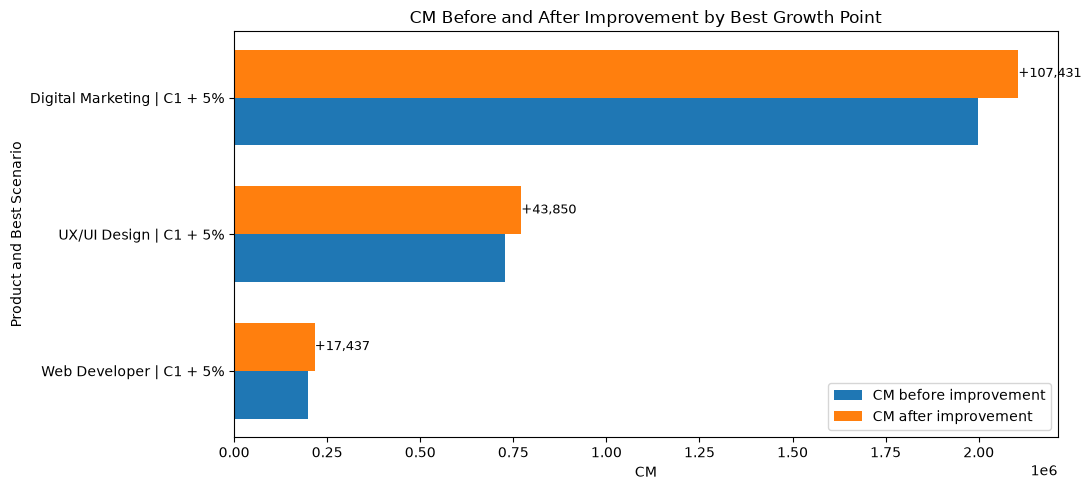

In [40]:
best_growth_plot = best_growth_points.sort_values(
    'Scenario CM',
    ascending=True
).copy()

y = np.arange(len(best_growth_plot['Product']))
height = 0.35

plt.figure(figsize=(11, 5))

plt.barh(
    y - height / 2,
    best_growth_plot['Baseline CM'],
    height,
    label='CM before improvement'
)

plt.barh(
    y + height / 2,
    best_growth_plot['Scenario CM'],
    height,
    label='CM after improvement'
)

for i, row in best_growth_plot.iterrows():
    plt.text(
        row['Scenario CM'],
        list(best_growth_plot.index).index(i) + height / 2,
        f"+{row['CM Uplift']:,.0f}",
        va='center',
        fontsize=9
    )

plt.yticks(
    y,
    best_growth_plot['Product'] + ' | ' + best_growth_plot['Scenario']
)

plt.xlabel('CM')
plt.ylabel('Product and Best Scenario')
plt.title('CM Before and After Improvement by Best Growth Point')
plt.legend()

plt.tight_layout()
plt.show()

### Growth Point Findings

To identify growth points, a baseline scenario analysis with a 5% metric change was used:

- `UA + 5%`;
- `C1 + 5%`;
- `AOV + 5%`;
- `APC + 5%`;
- `CPA - 5%`.

The scenario analysis showed that for all three products with customers, the best growth point is improving `C1` by 5%, meaning an increase in lead-to-customer conversion.

* For `Digital Marketing`, the `C1 + 5%` scenario increases `CM` from 1,999,087.46 to 2,106,518.00. The absolute uplift is 107,430.55.

* For `UX/UI Design`, the `C1 + 5%` scenario increases `CM` from 727,476.10 to 771,326.07. The absolute uplift is 43,849.98.

* For `Web Developer`, the `C1 + 5%` scenario increases `CM` from 199,223.22 to 216,660.55. The absolute uplift is 17,437.33.

**It is important to note that the `C1 + 5%`, `AOV + 5%` and `APC + 5%` scenarios produce the same `CM` uplift within each product.** This follows from the multiplicative structure of the formula:

`CM = UA * (AOV * APC * C1 - CPA)`

With the same percentage increase in one of the multipliers, the final effect on `CM` is the same. However, `C1` is selected for the experiment because it is a conversion metric that can be tested through product, marketing or sales hypotheses.

For the experiment, `C1` is used as one of the key growth metrics. **The expected hypothesis effect is set at 10% to test a more visible change within a short-term A/B test.**


# Hypothesis and Experiment Duration Calculation

The scenario analysis showed that one of the key growth points is `C1` — lead-to-customer conversion.

For the experiment calculation, I use the overall business-level `C1`, not product-level `C1`. This makes it possible to evaluate the experiment at the full funnel level rather than for a single product.

## Hypothesis

If an updated first-contact and follow-up communication scenario is implemented for new leads, lead-to-customer conversion (`C1`) will increase by at least 10% compared with the current level within 14 days.

## Experiment Stop Condition

The experiment stops when the required number of observations is reached in both control and test groups.

The calculation uses the formula from the course methodology:

`n = 16 * p * (1 - p) / x²`

where:

- `p` — baseline conversion;
- `x` — target conversion after the expected improvement according to the course methodology;
- `n` — size of one group;
- `2 * n` — total sample size for control and test groups.


In [41]:
# Experiment parameters

experiment_effect = 0.10
experiment_limit_days = 14

p = total_C1
x = p * (1 + experiment_effect)

experiment_hypothesis = pd.DataFrame({
    'Metric': [
        'Hypothesis name',
        'Target metric',
        'Baseline C1 (p), %',
        'Expected C1 uplift',
        'Target C1 (x), %',
        'Duration limit'
    ],
    'Value': [
        'Improve lead-to-customer conversion',
        'C1',
        round(p * 100, 2),
        '+10%',
        round(x * 100, 2),
        '14 days'
    ]
})

experiment_hypothesis


,Metric,Value
0,Hypothesis name,Improve lead-to-customer conversion
1,Target metric,C1
2,"Baseline C1 (p), %",4.52
3,Expected C1 uplift,+10%
4,"Target C1 (x), %",4.98
5,Duration limit,14 days


### Average Daily Lead Volume

To estimate experiment duration, I need to understand how many new leads appear on average per day.

Since final `UA` was taken from the `Contacts` table, average daily lead volume is also calculated using `contacts['Created Time']`.

Average daily `UA` is rounded to an integer because experiment duration is calculated based on real leads, not fractional values.


In [42]:
contacts_for_daily_ua = contacts[
    contacts['Created Time'].notna()
].copy()

contacts_period_start = contacts_for_daily_ua['Created Time'].min()
contacts_period_end = contacts_for_daily_ua['Created Time'].max()

contacts_period_days = (contacts_period_end - contacts_period_start).days + 1

daily_ua_raw = scalar_safe_divide(
    contacts_for_daily_ua['Id'].nunique(dropna=True),
    contacts_period_days
)

daily_ua = round(daily_ua_raw)

daily_ua_summary = pd.DataFrame({
    'Metric': [
        'Period start date',
        'Period end date',
        'Number of days in period',
        'UA',
        'Average daily UA'
    ],
    'Value': [
        contacts_period_start,
        contacts_period_end,
        contacts_period_days,
        contacts_for_daily_ua['Id'].nunique(dropna=True),
        daily_ua
    ]
})

daily_ua_summary


,Metric,Value
0,Period start date,2023-06-27 11:28:00
1,Period end date,2024-06-21 15:30:00
2,Number of days in period,361
3,UA,18548
4,Average daily UA,51


In [43]:
sample_per_group = 16 * p * (1 - p) / (x ** 2)

sample_per_group_ceil = np.ceil(sample_per_group)
total_sample_ceil = sample_per_group_ceil * 2

experiment_days = np.ceil(
    scalar_safe_divide(total_sample_ceil, daily_ua)
)

experiment_summary = pd.DataFrame([{
    'Baseline C1 (p), %': round(p * 100, 2),
    'Target C1 (x), %': round(x * 100, 2),
    'Sample size per group (n)': sample_per_group_ceil,
    'Total sample size (2*n)': total_sample_ceil,
    'Average daily UA': daily_ua,
    'Experiment duration, days': experiment_days,
    'Feasible within 14 days': 'Yes' if experiment_days <= experiment_limit_days else 'No'
}])

experiment_summary


,"Baseline C1 (p), %","Target C1 (x), %",Sample size per group (n),Total sample size (2*n),Average daily UA,"Experiment duration, days",Feasible within 14 days
0,4.52,4.98,280.00,560.00,51,11.00,Yes


### Hypothesis and Experiment Duration Findings

The selected experiment metric is `C1` — lead-to-customer conversion. This choice is based on the scenario analysis, which showed that improving `C1` is one of the key growth points for increasing `CM`.

Unlike the product-level analysis, the experiment duration calculation uses **overall business-level `C1`**, not conversion by individual products. This allows the experiment to be evaluated at the full sales funnel level and to use the overall flow of new leads.

The hypothesis is: if an updated first-contact and follow-up communication scenario is implemented for new leads, lead-to-customer conversion (`C1`) will increase by at least 10% compared with the current level within 14 days.

Baseline conversion `C1` is 4.52%. The target value after the expected 10% uplift is 4.98%.

The sample size was calculated using the formula:

`n = 16 * p * (1 - p) / x²`

where `p` is baseline conversion and `x` is target conversion after the expected improvement.

According to the calculation, the required size of one group is 280 observations. The total sample size for control and test groups is 560 observations.

Average daily lead flow is 51 leads per day. At this traffic volume, the experiment should take approximately 11 days.

Therefore, **the experiment can be completed within the 14-day limit**.

This means the hypothesis is suitable for a short-term A/B test.


## Exporting Unit Economics Tables for the Dashboard

At this step, I save the final unit economics tables as separate CSV files.

These files will be used in the Dash application, so unit economics calculations do not need to be duplicated inside the dashboard.

The calculation logic remains in `04_unit_economics`, while the dashboard is responsible only for visualizing the prepared results.


In [44]:
# Folder for dashboard-ready aggregates

DASHBOARD_DATA_PATH = PROJECT_ROOT / 'data' / 'processed'
DASHBOARD_DATA_PATH.mkdir(parents=True, exist_ok=True)

DASHBOARD_DATA_PATH


PosixPath('/Users/uliakardenasvalin/Documents/Аналитик данных/online-school-performance-analytics-portfolio/data/processed')

In [45]:
# Export final unit economics tables for the Dash application

unit_economics_total.to_csv(
    DASHBOARD_DATA_PATH / 'unit_economics_total.csv',
    index=False
)

unit_economics_display.to_csv(
    DASHBOARD_DATA_PATH / 'unit_economics_display.csv',
    index=False
)

products_status.to_csv(
    DASHBOARD_DATA_PATH / 'products_status.csv',
    index=False
)

revenue_comparison.to_csv(
    DASHBOARD_DATA_PATH / 'revenue_comparison.csv',
    index=False
)

unit_economics_check_df.to_csv(
    DASHBOARD_DATA_PATH / 'unit_economics_check.csv',
    index=False
)

growth_scenarios_display.to_csv(
    DASHBOARD_DATA_PATH / 'growth_scenarios_display.csv',
    index=False
)

best_growth_points_display.to_csv(
    DASHBOARD_DATA_PATH / 'best_growth_points.csv',
    index=False
)

experiment_hypothesis.to_csv(
    DASHBOARD_DATA_PATH / 'experiment_hypothesis.csv',
    index=False
)

daily_ua_summary.to_csv(
    DASHBOARD_DATA_PATH / 'daily_ua_summary.csv',
    index=False
)

experiment_summary.to_csv(
    DASHBOARD_DATA_PATH / 'experiment_summary.csv',
    index=False
)


In [46]:
# Check which files were exported

exported_files = sorted([
    file.name for file in DASHBOARD_DATA_PATH.glob('*.csv')
])

exported_files


['best_growth_points.csv',
 'calls_clean.csv',
 'contacts_clean.csv',
 'daily_ua_summary.csv',
 'deals_clean.csv',
 'experiment_hypothesis.csv',
 'experiment_summary.csv',
 'growth_scenarios_display.csv',
 'products_status.csv',
 'revenue_comparison.csv',
 'spend_clean.csv',
 'unit_economics_check.csv',
 'unit_economics_display.csv',
 'unit_economics_total.csv']